**Name:** Kavin.J.S

**Roll Number:** CH.SC.U4CSE24119

# Exercise 5.8 Q2 - Linear Regression on Body Weight Prediction

**Dataset**: Weight, Height, Age, Gender (example dataset from Lab Activity Book)

**Goal**: Predict Weight (dependent variable) using Height, Age, and Gender (independent variables) using Multiple Linear Regression.

### Importing Required Libraries

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import matplotlib.pyplot as plt
import numpy as np

### Creating the Dataset
Since this is a small example dataset given directly in the exercise, it is created manually here.

In [2]:
data = pd.DataFrame({
    'Weight': [79, 69, 73, 95, 82, 55, 69, 71, 64, 69],
    'Height': [1.80, 1.68, 1.82, 1.70, 1.87, 1.55, 1.50, 1.78, 1.67, 1.64],
    'Age':    [35, 39, 25, 60, 27, 18, 89, 42, 16, 52],
    'Gender': ['Male','Male','Male','Male','Male','Female','Female','Female','Female','Female']
})
data

,Weight,Height,Age,Gender
0,79,1.80,35,Male
1,69,1.68,39,Male
2,73,1.82,25,Male
3,95,1.70,60,Male
4,82,1.87,27,Male
5,55,1.55,18,Female
6,69,1.50,89,Female
7,71,1.78,42,Female
8,64,1.67,16,Female
9,69,1.64,52,Female


### Checking for any null values in dataset

In [3]:
data.isnull().sum()

Weight    0
Height    0
Age       0
Gender    0
dtype: int64

### Encoding the Gender column
Gender is a categorical variable, so it is encoded as: Male = 1, Female = 0.

In [4]:
data['Gender'] = data['Gender'].map({'Male': 1, 'Female': 0})
data

,Weight,Height,Age,Gender
0,79,1.80,35,1
1,69,1.68,39,1
2,73,1.82,25,1
3,95,1.70,60,1
4,82,1.87,27,1
5,55,1.55,18,0
6,69,1.50,89,0
7,71,1.78,42,0
8,64,1.67,16,0
9,69,1.64,52,0


### Assigning Dependent and Independent variables

In [5]:
x = data[['Height', 'Age', 'Gender']].values
y = data[['Weight']].values

### Splitting the dataset into Training and Testing Dataset

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x, y,
        test_size=0.2, random_state=42)

display(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

(8, 3)

(8, 1)

(2, 3)

(2, 1)

### Fitting the Model (Multiple Linear Regression)

In [7]:
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print('Predicted Weights:\n', y_pred)
print('\nActual Weights:\n', y_test)

Predicted Weights:
 [[56.85651025]
 [79.10576115]]

Actual Weights:
 [[64]
 [69]]


### Model Coefficients

In [8]:
print('Intercept (b0):', model.intercept_)
print('Coefficients [Height, Age, Gender] (b1, b2, b3):', model.coef_)

print('\nRegression Equation:')
print(f'Weight = {model.intercept_[0]:.2f} + ({model.coef_[0][0]:.2f} * Height) '
      f'+ ({model.coef_[0][1]:.2f} * Age) + ({model.coef_[0][2]:.2f} * Gender)')

Intercept (b0): [-3.05521724]
Coefficients [Height, Age, Gender] (b1, b2, b3): [[32.8353363   0.31729474 14.62311848]]

Regression Equation:
Weight = -3.06 + (32.84 * Height) + (0.32 * Age) + (14.62 * Gender)


### Model Evaluation Metrics

In [9]:
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, y_pred)

print('Mean Squared Error (MSE):', mse)
print('Root Mean Squared Error (RMSE):', rmse)
print('R-squared (R2) Score:', r2)

Mean Squared Error (MSE): 76.57792714844274
Root Mean Squared Error (RMSE): 8.750881506936471
R-squared (R2) Score: -11.252468343750838


### Fitting the model on the FULL dataset (for full-sample evaluation, since the dataset is very small)

In [10]:
model_full = LinearRegression()
model_full.fit(x, y)
y_pred_full = model_full.predict(x)

r2_full = metrics.r2_score(y, y_pred_full)
mse_full = metrics.mean_squared_error(y, y_pred_full)

print('Intercept (b0):', model_full.intercept_)
print('Coefficients [Height, Age, Gender]:', model_full.coef_)
print('R-squared (R2) Score on full data:', r2_full)
print('MSE on full data:', mse_full)

results = pd.DataFrame({
    'Actual Weight': y.flatten(),
    'Predicted Weight': y_pred_full.flatten()
})
results['Residual'] = results['Actual Weight'] - results['Predicted Weight']
results

Intercept (b0): [-24.40965469]
Coefficients [Height, Age, Gender]: [[47.37930785  0.29668529  8.92206984]]
R-squared (R2) Score on full data: 0.7535455935615615
MSE on full data: 26.03544349615665


,Actual Weight,Predicted Weight,Residual
0,79,80.179154,-1.179154
1,69,75.680379,-6.680379
2,73,78.159888,-5.159888
3,95,82.858356,12.141644
4,82,81.122224,0.877776
5,55,54.368608,0.631392
6,69,73.064298,-4.064298
7,71,72.386295,-1.386295
8,64,59.460754,4.539246
9,69,68.720045,0.279955


### Plot: Actual vs Predicted Weight (full dataset)

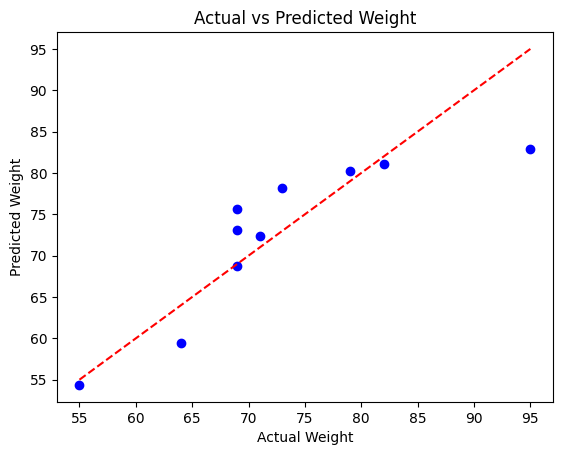

In [11]:
plt.scatter(results['Actual Weight'], results['Predicted Weight'], color='blue')
plt.plot([results['Actual Weight'].min(), results['Actual Weight'].max()],
         [results['Actual Weight'].min(), results['Actual Weight'].max()],
         color='red', linestyle='--')
plt.title('Actual vs Predicted Weight')
plt.xlabel('Actual Weight')
plt.ylabel('Predicted Weight')
plt.show()